In [14]:
from repitframework.Dataset.fvmn import FVMNDataset
from repitframework.config import TrainingConfig


start_time = 10.61
end_time = 10.64
time_step = 0.01


training_config = TrainingConfig()
dataset_true = FVMNDataset(
	training_config=training_config,
	first_training=False,
	data_path="/home/shilaj/repitframework/repitframework/Assets/natural_convection_case1_backup",
	start_time=start_time,
	end_time=end_time,
	time_step=time_step
)

dataset_pseudo = FVMNDataset(
	training_config=training_config,
	first_training=False,
	data_path="/home/shilaj/repitframework/repitframework/Assets/natural_convection_case1",
	start_time=start_time,
	end_time=end_time,
	time_step=0.01
)

data_true, label_true = dataset_true._prepare_inputs_and_labels()
data_pseudo, label_pseudo = dataset_pseudo._prepare_inputs_and_labels()

# temperature_true = data_true[:, :5]
# velocityX_true = data_true[:, 5:10]
# velocityY_true = data_true[:, 10:15]

# temperature_pseudo = data_pseudo[:, :5]
# velocityX_pseudo = data_pseudo[:, 5:10]
# velocityY_pseudo = data_pseudo[:, 10:15]

# temperature_true = data_true[:, 0:1]
# velocityX_true = data_true[:, 5:6]
# velocityY_true = data_true[:, 10:11]

# temperature_pseudo = data_pseudo[:, 0:1]
# velocityX_pseudo = data_pseudo[:, 5:6]
# velocityY_pseudo = data_pseudo[:, 10:11]

temperature_true = label_true[:, 0:1]
velocityX_true = label_true[:, 1:2]
velocityY_true = label_true[:, 2:3]
temperature_pseudo = label_pseudo[:, 0:1]
velocityX_pseudo = label_pseudo[:, 1:2]
velocityY_pseudo = label_pseudo[:, 2:3]


# with open("/home/shilaj/repitframework/repitframework/ModelDump/natural_convection_case1/denorm_metrics.json", "r") as f:
# 	denorm_metrics = json.load(f)

# input_MEAN = np.array(denorm_metrics["input_MEAN"])
# input_STD = np.array(denorm_metrics["input_STD"])

# data_true = FVMNDataset.denormalize(
# 	data_true,
# 	input_MEAN,
# 	input_STD
# )

# data_pseudo = FVMNDataset.denormalize(
# 	data_pseudo,
# 	input_MEAN,
# 	input_STD
# )

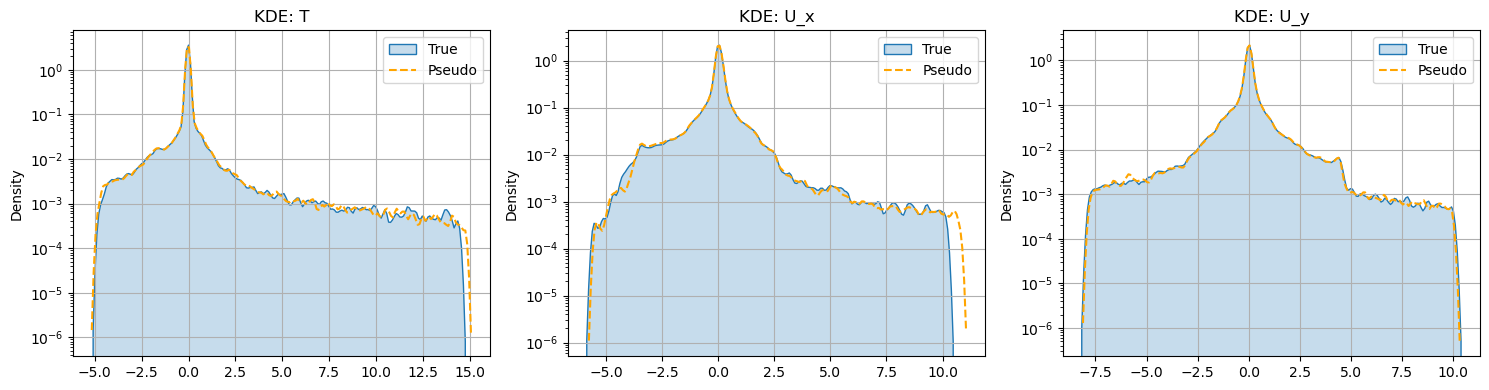

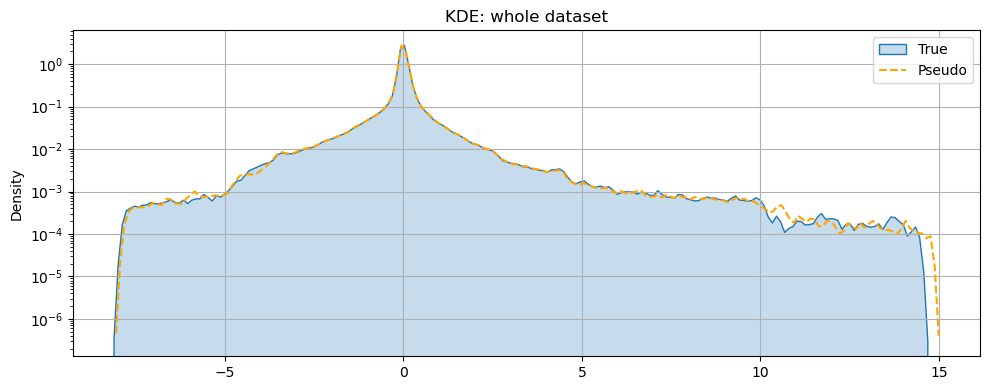

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

variables = ["T", "U_x", "U_y"]

for i, var in enumerate(variables):
	ax = axs[i]
	# index = i*5
	# sns.kdeplot(data_true[:, index], label="True", fill=True, ax=ax)
	# sns.kdeplot(data_pseudo[:, index], label="Pseudo", linestyle="--", fill=False, ax=ax, color="orange")
	# ax.hist(label_true[:, i], bins=10000, density=True, alpha=0.3, label="True")
	# ax.hist(label_pseudo[:, i], bins=10000, density=True, alpha=0.3, label="Pseudo")
	sns.kdeplot(label_true[:, i], label="True", fill=True, ax=ax)
	sns.kdeplot(label_pseudo[:, i], label="Pseudo", linestyle="--", fill=False, ax=ax, color="orange")
	ax.set_yscale("log")
	ax.set_title(f"KDE: {var}")
	ax.legend()
	ax.grid(True)

plt.tight_layout()
plt.show()


# plot a single plot for whole data
fig, ax = plt.subplots(figsize=(10, 4))
sns.kdeplot(label_true.ravel(), label="True", fill=True, ax=ax)
sns.kdeplot(label_pseudo.ravel(), label="Pseudo", linestyle="--", fill=False, ax=ax, color="orange")
ax.set_yscale("log")
ax.set_title(f"KDE: whole dataset")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


# Cumulative Density Function

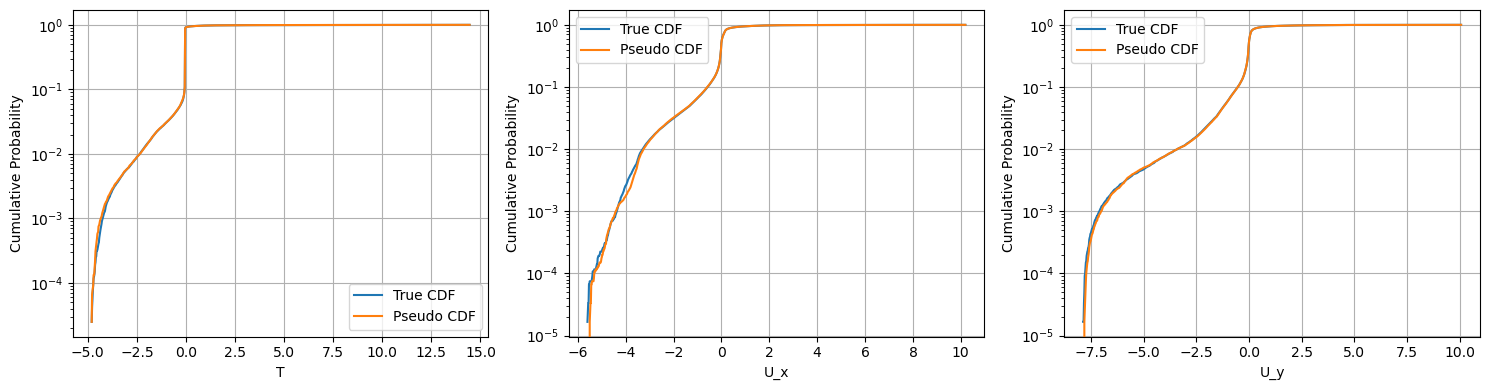

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

variables = ["T", "U_x", "U_y"]

for i, var in enumerate(variables):
	ax = axs[i]
	index = i*5
	# count_true, bins = np.histogram(data_true[:, index], bins=1000, density=True)
	count_true, bins = np.histogram(label_true[:, i], bins=1000, density=True)
	cdf_true = np.cumsum(count_true) / np.sum(count_true)

	count_pseudo, _ = np.histogram(label_pseudo[:, i], bins=bins, density=True)
	# count_pseudo, _ = np.histogram(data_pseudo[:, index], bins=bins, density=True)
	cdf_pseudo = np.cumsum(count_pseudo) / np.sum(count_pseudo)

	ax.plot(bins[:-1], cdf_true, label="True CDF")
	ax.plot(bins[:-1], cdf_pseudo, label="Pseudo CDF")
	# ax.title(f"CDF Comparison: {var}")
	ax.grid(True)
	ax.legend()
	ax.set_xlabel(var)
	ax.set_ylabel("Cumulative Probability")
	ax.set_yscale("log")
plt.tight_layout()
plt.show()



# Jensen-Shannon Divergence

In [5]:
import numpy as np
from scipy.stats import entropy

def compute_jsd(true, pseudo, base=np.e):
	"""
	Compute the Jensen-Shannon Divergence between two 1D distributions.
	p and q must be arrays of probabilities (sum to 1).
	"""
	# Common bins
	bins = np.histogram_bin_edges(np.concatenate([true, pseudo]), bins=1000)
	p, _ = np.histogram(true, bins=bins, density=True)
	q, _ = np.histogram(pseudo, bins=bins, density=True)

	p = np.asarray(p)
	q = np.asarray(q)

	# Add smoothing to avoid log(0)
	p += 1e-10
	q += 1e-10

	# Normalize if needed
	p /= p.sum()
	q /= q.sum()

	m = 0.5 * (p + q)
	return 0.5 * entropy(p, m, base=base) + 0.5 * entropy(q, m, base=base)


print("Jensen-Shannon Divergence (JSD) for True and Pseudo Distributions:")
for i, var in enumerate(variables):
	# index = i*5
	jsd = compute_jsd(label_true[:, i], label_pseudo[:, i])
	print(f"{var}: {jsd:.4f}")
print("Whole JSD:", compute_jsd(label_true, label_pseudo))


Jensen-Shannon Divergence (JSD) for True and Pseudo Distributions:
T: 0.0026
U_x: 0.0025
U_y: 0.0023
Whole JSD: 0.0007552351196765919


# Computing the KL divergence

In [6]:
import numpy as np
from scipy.stats import entropy, skew, kurtosis

# Freedman-Diaconis rule for bin width
from scipy.stats import iqr
def get_optimal_bins(data):
	bin_width = 2 * iqr(data) / (len(data) ** (1/3))
	n_bins = int((data.max() - data.min()) / bin_width)
	return max(n_bins, 100)  # Ensure at least 10 bins


def compute_KL_divergence(data_true:np.ndarray, data_pseudo:np.ndarray) -> float:

	# Flatten the data
	data_true_flat = data_true.flatten()
	data_pseudo_flat = data_pseudo.flatten()

	n_bins = get_optimal_bins(np.concatenate([data_true_flat, data_pseudo_flat]))
	# Compute histograms
	counts_true, bin_edges = np.histogram(data_true_flat, bins=1000, density=True)
	counts_pseudo, _ = np.histogram(data_pseudo_flat, bins=bin_edges, density=True)

	# Add a small value to avoid division by zero
	counts_true += 1e-8
	counts_pseudo += 1e-8

	# Compute KL divergence
	kl_divergence = entropy(counts_true, counts_pseudo)
	return kl_divergence
print(f"KL divergence for whole data: {compute_KL_divergence(label_true, label_pseudo)}")
print(f"Kl divergence for Temperature: {compute_KL_divergence(temperature_true, temperature_pseudo)}")
print(f"Kl divergence for velocity_x: {compute_KL_divergence(velocityX_true, velocityX_pseudo)}")
print(f"Kl divergence for velocity_y: {compute_KL_divergence(velocityY_true, velocityY_pseudo)}")

KL divergence for whole data: 0.00492697818575104
Kl divergence for Temperature: 0.021025657158039005
Kl divergence for velocity_x: 0.021000899618157133
Kl divergence for velocity_y: 0.01830367615914019


In [9]:
print(f"Skewness for whole data (true vs pseudo): {skew(label_true.flatten())} vs {skew(label_pseudo.flatten())}")
print(f"Skewness for Temperature (true vs pseudo): {skew(temperature_true.flatten())} vs {skew(temperature_pseudo.flatten())}")
print(f"Skewness for velocity_x (true vs pseudo): {skew(velocityX_true.flatten())} vs {skew(velocityX_pseudo.flatten())}")
print(f"Skewness for velocity_y (true vs pseudo): {skew(velocityY_true.flatten())} vs {skew(velocityY_pseudo.flatten())}")

Skewness for whole data (true vs pseudo): 3.075018437288598 vs 2.456165149414346
Skewness for Temperature (true vs pseudo): 7.309162634876825 vs 7.297645158787207
Skewness for velocity_x (true vs pseudo): 1.7904320409361307 vs 2.008098388318961
Skewness for velocity_y (true vs pseudo): 0.41845567889206986 vs -1.1156971126976256


In [209]:
print(f"Kurtosis for whole data (true vs pseudo): {kurtosis(label_true.flatten())} vs {kurtosis(label_pseudo.flatten())}")
print(f"Kurtosis for Temperature (true vs pseudo): {kurtosis(temperature_true.flatten())} vs {kurtosis(temperature_pseudo.flatten())}")
print(f"Kurtosis for velocity_x (true vs pseudo): {kurtosis(velocityX_true.flatten())} vs {kurtosis(velocityX_pseudo.flatten())}")
print(f"Kurtosis for velocity_y (true vs pseudo): {kurtosis(velocityY_true.flatten())} vs {kurtosis(velocityY_pseudo.flatten())}")

Kurtosis for whole data (true vs pseudo): 45.10505383936792 vs 43.922315572875945
Kurtosis for Temperature (true vs pseudo): 88.74627691920705 vs 87.5609250265197
Kurtosis for velocity_x (true vs pseudo): 24.579180970304332 vs 34.50169396125964
Kurtosis for velocity_y (true vs pseudo): 24.254938186288836 vs 19.741383067104245


# Feature space analysis with PCA and t-SNE

In [210]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# X_true and X_pseudo are arrays of shape (N_samples, 3) containing [T, Ux, Uy]
X = np.vstack([label_true, label_pseudo])
y = np.array([0]*len(label_true) + [1]*len(label_pseudo))  # labels: 0=true, 1=pseudo

# PCA projection to 2 components
pca = PCA(n_components=2)
Z_pca = pca.fit_transform(X)

# t-SNE embedding to 2D
Z_tsne = TSNE(n_components=2, perplexity=30, random_state=0).fit_transform(X)


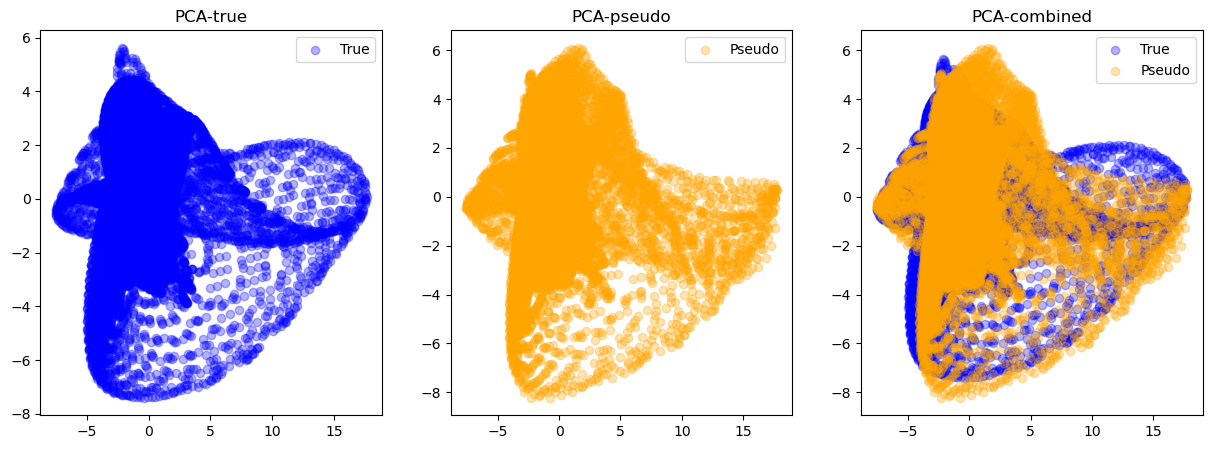

In [211]:
import matplotlib.pyplot as plt
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,5))
ax1.scatter(Z_pca[y==0,0], Z_pca[y==0,1], c='blue', label='True', alpha=0.3)
# ax1.scatter(Z_pca[y==1,0], Z_pca[y==1,1], c='orange', label='Pseudo', alpha=0.3)
ax1.set_title("PCA-true"); ax1.legend()

# ax2.scatter(Z_tsne[y==0,0], Z_tsne[y==0,1], c='blue', label='True', alpha=0.3)
# ax2.scatter(Z_tsne[y==1,0], Z_tsne[y==1,1], c='orange', label='Pseudo', alpha=0.3)
ax2.scatter(Z_pca[y==1,0], Z_pca[y==1,1], c='orange', label='Pseudo', alpha=0.3)
ax2.set_title("PCA-pseudo"); ax2.legend()

ax3.scatter(Z_pca[y==0,0], Z_pca[y==0,1], c='blue', label='True', alpha=0.3)
ax3.scatter(Z_pca[y==1,0], Z_pca[y==1,1], c='orange', label='Pseudo', alpha=0.3)
ax3.set_title("PCA-combined"); ax3.legend()
plt.show()


In [ ]:
print("Explained variance ratio (True):", pca_true.explained_variance_ratio_)
print("Explained variance ratio (Pseudo):", pca_pseudo.explained_variance_ratio_)


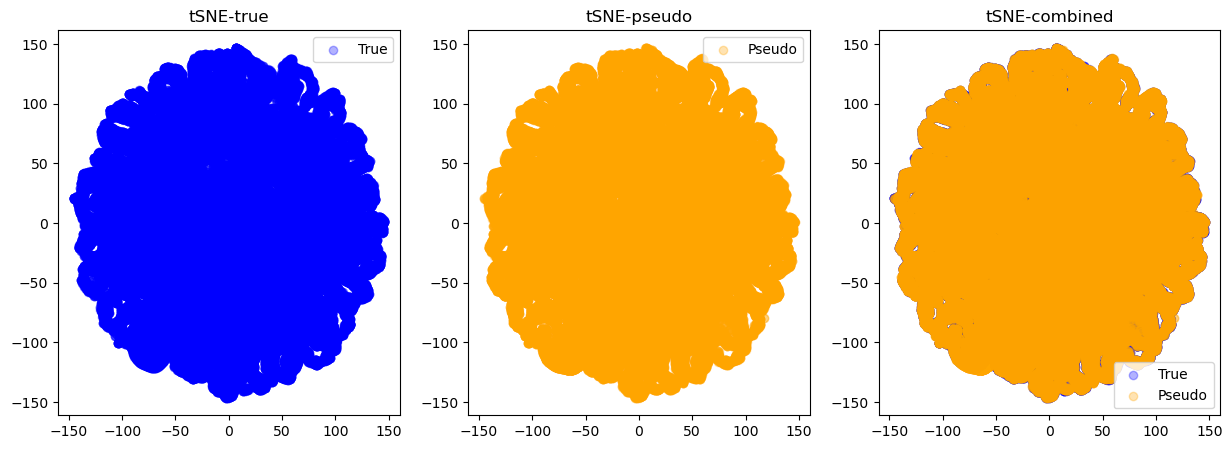

In [212]:
import matplotlib.pyplot as plt
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,5))
ax1.scatter(Z_tsne[y==0,0], Z_tsne[y==0,1], c='blue', label='True', alpha=0.3)
ax1.set_title("tSNE-true"); ax1.legend()

ax2.scatter(Z_tsne[y==1,0], Z_tsne[y==1,1], c='orange', label='Pseudo', alpha=0.3)
ax2.set_title("tSNE-pseudo"); ax2.legend()

ax3.scatter(Z_tsne[y==0,0], Z_tsne[y==0,1], c='blue', label='True', alpha=0.3)
ax3.scatter(Z_tsne[y==1,0], Z_tsne[y==1,1], c='orange', label='Pseudo', alpha=0.3)
ax3.set_title("tSNE-combined"); ax3.legend()
plt.show()

# Spatial flow-field visualizations

Text(0.5, 1.0, 'Streamlines: blue=True, red=Pseudo')

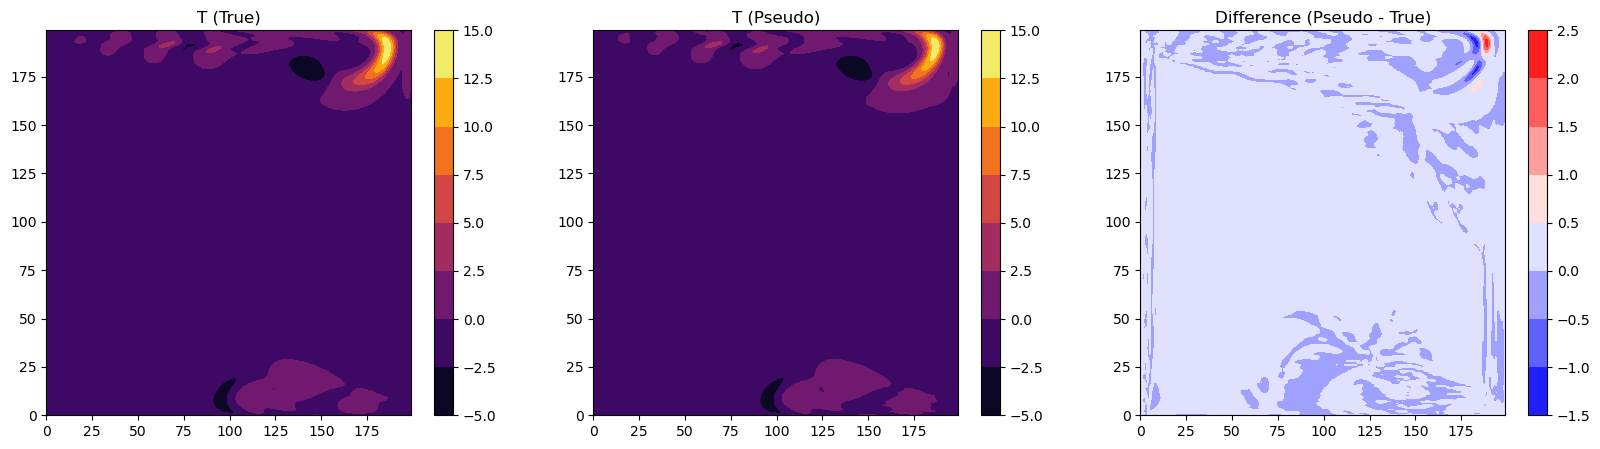

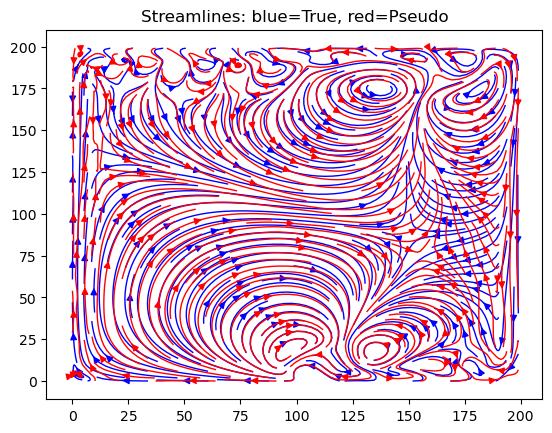

In [15]:
# Assuming 2D arrays T_true, T_pseudo, Ux_true, Uy_true, etc., and coordinates X, Y
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import torch
import numpy as np

T_true = temperature_true[40000:80000, 0].reshape(200, 200)
T_pseudo = temperature_pseudo[40000:80000, 0].reshape(200, 200)
Ux_true = velocityX_true[40000:80000, 0].reshape(200, 200)
Ux_pseudo = velocityX_pseudo[40000:80000, 0].reshape(200, 200)
Uy_true = velocityY_true[40000:80000, 0].reshape(200, 200)
Uy_pseudo = velocityY_pseudo[40000:80000, 0].reshape(200, 200)
# Temperature contour comparison
X = np.linspace(0, 199, 200, dtype=int)
Y = np.linspace(0, 199, 200, dtype=int)
X, Y = np.meshgrid(X, Y)
fig, ax = plt.subplots(1, 3, figsize=(20,5))
c1 = ax[0].contourf(X, Y, T_true, cmap='inferno'); plt.colorbar(c1, ax=ax[0]); ax[0].set_title("T (True)")
c2 = ax[1].contourf(X, Y, T_pseudo, cmap='inferno'); plt.colorbar(c2, ax=ax[1]); ax[1].set_title("T (Pseudo)")
c3 = ax[2].contourf(X, Y, T_pseudo - T_true, cmap='bwr'); plt.colorbar(c3, ax=ax[2]); ax[2].set_title("Difference (Pseudo - True)")



# Streamlines (using quiver or streamplot for velocity)
plt.figure()
plt.streamplot(X, Y, Ux_true, Uy_true, color='blue', linewidth=1, density=2, arrowsize=1)
plt.streamplot(X, Y, Ux_pseudo, Uy_pseudo, color='red', linewidth=1, density=2, arrowsize=1)
plt.title("Streamlines: blue=True, red=Pseudo")


# Spectral analysis (Energy Spectrum)

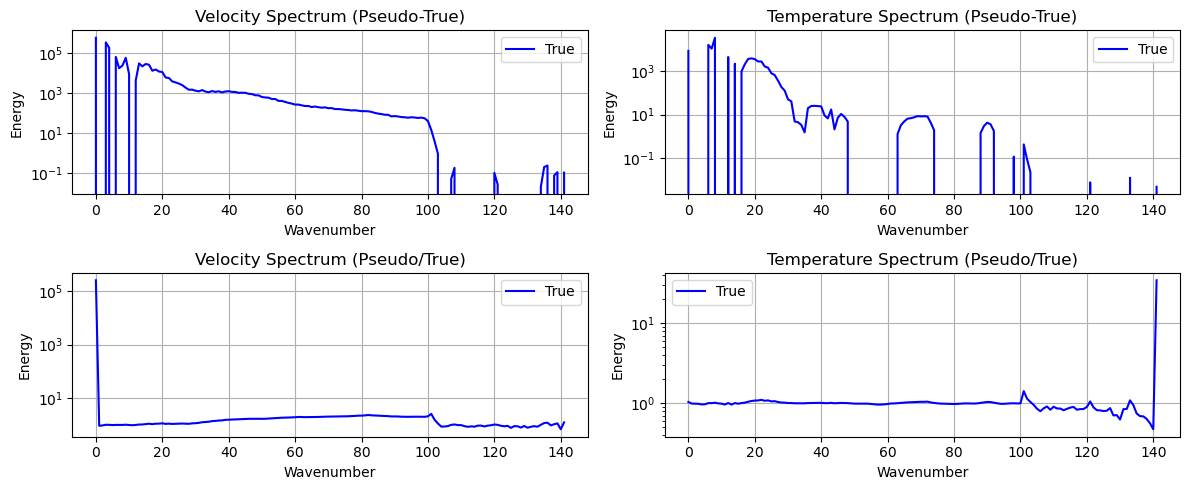

In [16]:
import numpy as np
import matplotlib.pyplot as plt

T_true = temperature_true[80000:, 0].reshape(200, 200)
T_pseudo = temperature_pseudo[80000:, 0].reshape(200, 200)
Ux_true = velocityX_true[80000:, 0].reshape(200, 200)
Ux_pseudo = velocityX_pseudo[80000:, 0].reshape(200, 200)
Uy_true = velocityY_true[80000:, 0].reshape(200, 200)
Uy_pseudo = velocityY_pseudo[80000:, 0].reshape(200, 200)
# === Fourier Transforms ===
fft_ux_true = np.fft.fft2(Ux_true)
fft_ux_pseudo = np.fft.fft2(Ux_pseudo)
fft_uy_true = np.fft.fft2(Uy_true)
fft_uy_pseudo = np.fft.fft2(Uy_pseudo)
fft_T_true = np.fft.fft2(T_true)
fft_T_pseudo = np.fft.fft2(T_pseudo)

# === Energy ===
E_vel_true = np.abs(fft_ux_true)**2 + np.abs(fft_uy_true)**2
E_vel_pseudo = np.abs(fft_ux_pseudo)**2 + np.abs(fft_uy_pseudo)**2
E_T_true = np.abs(fft_T_true)**2
E_T_pseudo = np.abs(fft_T_pseudo)**2

# === Shift ===
E_vel_true = np.fft.fftshift(E_vel_true)
E_vel_pseudo = np.fft.fftshift(E_vel_pseudo)
E_T_true = np.fft.fftshift(E_T_true)
E_T_pseudo = np.fft.fftshift(E_T_pseudo)

# === Radial Spectrum ===
def radial_spectrum(E: np.ndarray) -> np.ndarray:
	nx, ny = E.shape
	cx, cy = nx // 2, ny // 2
	y, x = np.indices((nx, ny))
	r = np.sqrt((x - cx)**2 + (y - cy)**2).astype(int)
	tbin = np.bincount(r.ravel(), E.ravel())
	nr = np.bincount(r.ravel())
	return tbin / (nr + 1e-10)

E_vel_true_radial = radial_spectrum(E_vel_true)
E_vel_pseudo_radial = radial_spectrum(E_vel_pseudo)
E_T_true_radial = radial_spectrum(E_T_true)
E_T_pseudo_radial = radial_spectrum(E_T_pseudo)

k = np.arange(len(E_T_true_radial))

# === Plotting ===
fig, axs = plt.subplots(2, 2, figsize=(12, 5))

# Velocity Spectrum
axs[0,0].plot(k, E_vel_pseudo_radial-E_vel_true_radial, label='True', color='blue')
# axs[0].plot(k, E_vel_pseudo_radial, label='Pseudo', color='red', linestyle='--')
axs[0,0].set_title("Velocity Spectrum (Pseudo-True)")
axs[0,0].set_xlabel("Wavenumber")
axs[0,0].set_ylabel("Energy")
axs[0,0].set_yscale("log")
axs[0,0].grid(True)
axs[0,0].legend()

# Temperature Spectrum
axs[0,1].plot(k, E_T_pseudo_radial-E_T_true_radial, label='True', color='blue')
# axs[1].plot(k, E_T_pseudo_radial, label='Pseudo', color='red', linestyle='--')
axs[0,1].set_title("Temperature Spectrum (Pseudo-True)")
axs[0,1].set_xlabel("Wavenumber")
axs[0,1].set_ylabel("Energy")
axs[0,1].set_yscale("log")
axs[0,1].grid(True)
axs[0,1].legend()

# Velocity Spectrum
axs[1,0].plot(k, E_vel_pseudo_radial/E_vel_true_radial, label='True', color='blue')
axs[1,0].set_title("Velocity Spectrum (Pseudo/True)")
axs[1,0].set_xlabel("Wavenumber")
axs[1,0].set_ylabel("Energy")
axs[1,0].set_yscale("log")
axs[1,0].grid(True)
axs[1,0].legend()

# Temperature Spectrum
axs[1,1].plot(k, E_T_pseudo_radial/E_T_true_radial, label='True', color='blue')
axs[1,1].set_title("Temperature Spectrum (Pseudo/True)")
axs[1,1].set_xlabel("Wavenumber")
axs[1,1].set_ylabel("Energy")
axs[1,1].set_yscale("log")
axs[1,1].grid(True)
axs[1,1].legend()

plt.tight_layout()
plt.show()


In [5]:
fft_ux_pseudo

array([[-1.47282681e-01+0.00000000e+00j,  3.65186782e-01+1.11791158e+00j,
         3.65432916e-01+8.85566501e-01j, ...,
        -1.51036347e+00-2.13826779e+00j,  3.65432916e-01-8.85566501e-01j,
         3.65186782e-01-1.11791158e+00j],
       [-1.57523600e+03-2.25707891e+02j,  2.83849953e+03+4.63417964e+02j,
         9.52740679e+02+6.54917890e+02j, ...,
        -1.02886519e+03+8.66017719e+00j, -1.71358437e+03-3.10119512e+03j,
         4.03561434e+03-1.31749329e+03j],
       [-9.87867653e+02+1.15169883e+03j,  3.69295597e+03+1.61813058e+03j,
        -1.62363484e+03+2.33224507e+03j, ...,
         2.56845659e+02-2.67511068e+03j,  1.60803017e+03-2.79271502e+03j,
         4.68942847e+03+6.75636411e+02j],
       ...,
       [-1.17166938e+03-1.71547573e+03j,  1.51085922e+03-2.54110369e+03j,
         4.41240034e+03-1.67112240e+03j, ...,
        -8.16685928e+02+1.73493660e+03j, -3.52993455e+03-2.25326509e+03j,
         2.15010980e+03-1.65727393e+03j],
       [-9.87867653e+02-1.15169883e+03j,  4.

In [214]:
torch.mean(Ux_pseudo), torch.mean(Ux_true), torch.mean(Uy_pseudo), torch.mean(Uy_true)

(tensor(0.0045), tensor(1.9617e-05), tensor(0.0321), tensor(-3.3070e-05))

In [215]:
torch.std(Ux_pseudo), torch.std(Ux_true), torch.std(Uy_pseudo), torch.std(Uy_true)

(tensor(0.9638), tensor(0.9379), tensor(1.0002), tensor(0.9875))

### Actionable Tip:
Check mean(Ux) and mean(Uy) for true vs pseudo fields.

If discrepancy exists → consider centering the predicted velocity field or applying post-processing correction for global drift.

# High Order Statistics
## Feature Correlation (T vs Ux, T vs Uy, etc.)

In [ ]:
import numpy as np
import pandas as pd

# Stack all features for correlation matrix
def compute_correlations(T:np.ndarray, Ux:np.ndarray, Uy:np.ndarray) -> pd.DataFrame:
	df = pd.DataFrame({
		'T': T.flatten(),
		'Ux': Ux.flatten(),
		'Uy': Uy.flatten()
	})
	return df.corr()

print("Correlation Matrix (True):")
print(compute_correlations(T_true, Ux_true, Uy_true))

print("\nCorrelation Matrix (Pseudo):")
print(compute_correlations(T_pseudo, Ux_pseudo, Uy_pseudo))


Correlation Matrix (True):
           T        Ux        Uy
T   1.000000  0.523134  0.352900
Ux  0.523134  1.000000  0.322994
Uy  0.352900  0.322994  1.000000

Correlation Matrix (Pseudo):
           T        Ux        Uy
T   1.000000  0.525748  0.316853
Ux  0.525748  1.000000  0.313871
Uy  0.316853  0.313871  1.000000


## 2D Histograms (Joint Distributions)

Text(0.5, 1.0, 'Distribution Comparison (KDE)')

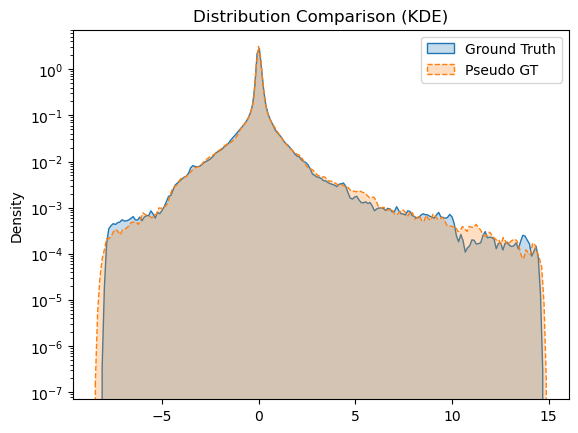

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(label_true.flatten(), label="Ground Truth", fill=True)
sns.kdeplot(label_pseudo.flatten(), label="Pseudo GT", fill=True, linestyle="--")
plt.yscale("log")
plt.legend(); plt.title("Distribution Comparison (KDE)")

# plt.plot(np.log(label_true + 1e-10) - np.log(label_pseudo + 1e-10))
# plt.title("Log Density Difference (log(P) - log(Q))")
# plt.xlabel("Sample index"); plt.ylabel("Log-Diff")



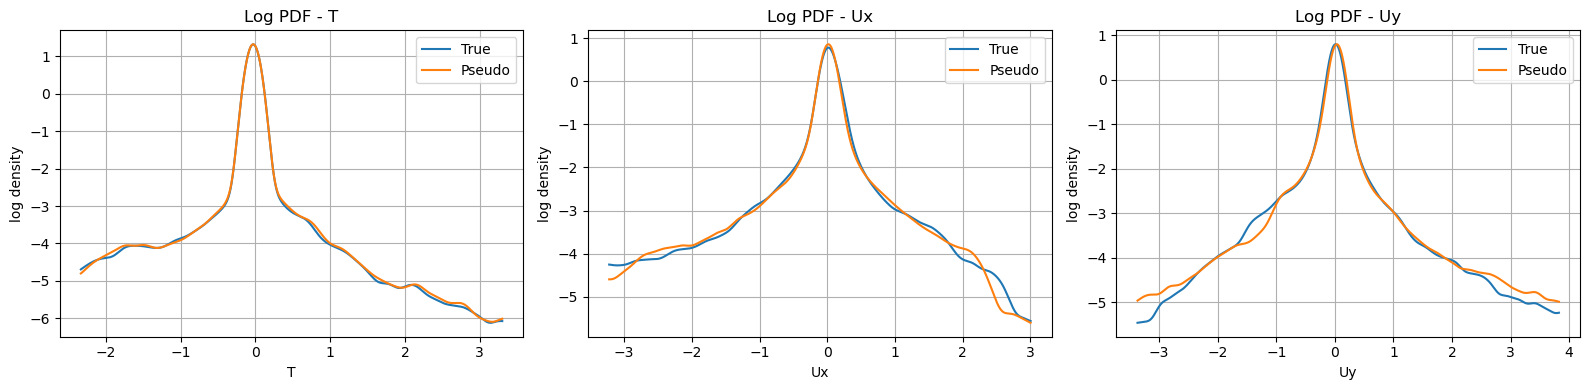

In [86]:
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

def plot_log_density_per_feature(label_sets: dict, n=40000):
	"""
	Plot log-probability densities for each feature (T, Ux, Uy) separately.
	
	Parameters:
	- label_sets: dict of {label_name: data_array of shape (N, 3)}
	- n: number of x-points for KDE evaluation
	"""

	feature_names = ["T", "Ux", "Uy"]
	num_features = 3

	# Combine all data to compute global x-axis range per feature
	all_data = np.vstack(list(label_sets.values()))
	x_ranges = [
		np.linspace(np.percentile(all_data[:, i], 1),
					np.percentile(all_data[:, i], 99), n)
		for i in range(num_features)
	]

	plt.figure(figsize=(16, 4))
	for i in range(num_features):  # T, Ux, Uy
		plt.subplot(1, 3, i + 1)

		for label, data in label_sets.items():
			kde = gaussian_kde(data[:, i])
			pdf = kde(x_ranges[i])  # avoid log(0)
			log_pdf = np.log(pdf)
			plt.plot(x_ranges[i], log_pdf, label=label)

		plt.title(f"Log PDF - {feature_names[i]}")
		plt.xlabel(feature_names[i])
		plt.ylabel("log density")
		plt.grid(True)
		plt.legend()

	plt.tight_layout()
	plt.show()


# label_sets = {
# 	"True": data_true[:, ::5],
# 	"Pseudo": data_pseudo[:, ::5]
# }
label_sets = {
	"True": label_true,
	"Pseudo": label_pseudo
}
plot_log_density_per_feature(label_sets)

Text(0.5, 1.0, 'Q-Q Plot of Error (Pseudo - True)')

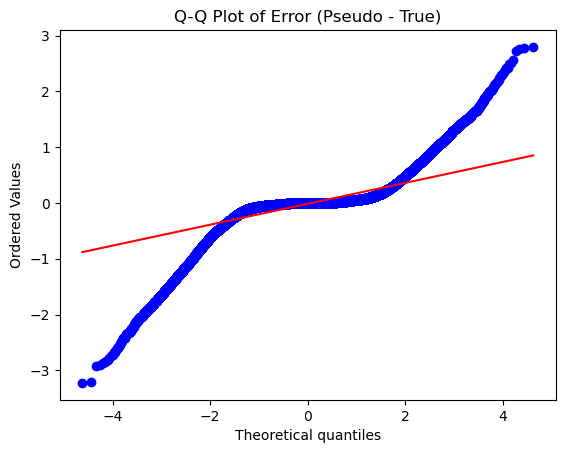

In [44]:
import scipy.stats as stats

stats.probplot(label_true.flatten() - label_pseudo.flatten(), dist="norm", plot=plt)
plt.title("Q-Q Plot of Error (Pseudo - True)")


# Analyzing loss landscape between True and 

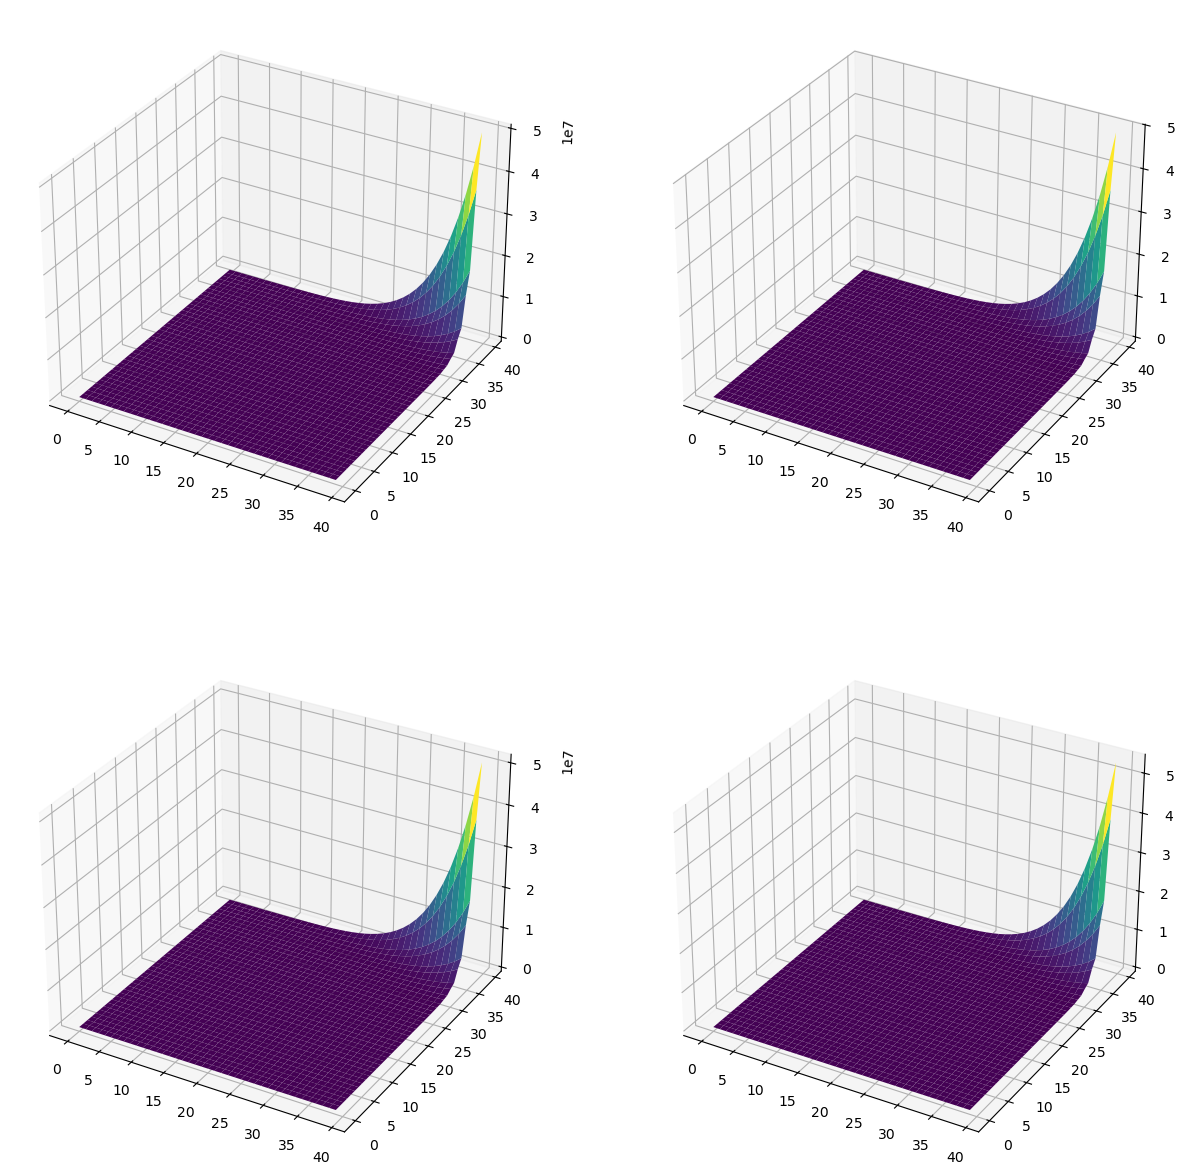

In [ ]:
from src_lla import viz_lla, metrics
from repitframework.DataLoader.loader import one_third_val
from repitframework.Models.FVMN.fvmn import FVMNetwork
from repitframework.config import TrainingConfig
import torch


training_config = TrainingConfig()
model = FVMNetwork(
	training_config=training_config,
)

checkpoint_path = "/home/shilaj/repitframework/repitframework/ModelDump/natural_convection_case1/init_model.pth"
checkpoint = torch.load(checkpoint_path, weights_only=True)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to('cuda:1')

optimizer = torch.optim.Adam(
	model.parameters(),
	lr=1e-1,
	weight_decay=1e-5
)

loss_fn = torch.nn.MSELoss()

train_loader1, _ = one_third_val(
	dataset=dataset_true,
	batch_size=10000
)
train_loader2, _ = one_third_val(
	dataset=dataset_pseudo,
	batch_size=10000
)
# Prepare metrics for both datasets
x_plot1, y_plot1 = next(iter(train_loader1))  # Dataset 1 sample
x_plot2, y_plot2 = next(iter(train_loader2))  # Dataset 2 sample

metric1 = metrics.Loss(loss_fn, x_plot1, y_plot1, device='cuda:1')
metric2 = metrics.Loss(loss_fn, x_plot2, y_plot2, device='cuda:1')

# Plot landscapes
viz_lla(model,metric2,device='cuda:1',normalization='filter',axes='random',to_save=True,to_viz=True, 
		viz_dir="/home/shilaj/repitframework/repitframework/ModelDump/natural_convection_case1",
		cur_name="loss_plotPSEUDO")


In [230]:
import json
with open("/home/shilaj/repitframework/repitframework/ModelDump/natural_convection_case1/denorm_metrics.json", "r") as f:
	denorm_metrics = json.load(f)
from repitframework.Dataset.fvmn import FVMNDataset

input_MEAN = np.array(denorm_metrics["input_MEAN"])
input_STD = np.array(denorm_metrics["input_STD"])
label_MEAN = np.array(denorm_metrics["label_MEAN"])
label_STD = np.array(denorm_metrics["label_STD"])

In [255]:
label_denormed_true = FVMNDataset.denormalize(
	label_true,
	label_MEAN,
	label_STD
)
label_denormed_pseudo = FVMNDataset.denormalize(
	label_pseudo,
	label_MEAN,
	label_STD
)

data_denormed_true = FVMNDataset.denormalize(
	data_true,
	input_MEAN,
	input_STD
)
data_denormed_pseudo = FVMNDataset.denormalize(
	data_pseudo,
	input_MEAN,
	input_STD
)
T_pseudo = data_denormed_pseudo[80000:, 0:1].reshape(200, 200)
T_true = data_denormed_true[80000:, 0:1].reshape(200, 200)

In [244]:
data_merged_true = data_denormed_true[:, ::5] + label_denormed_true
data_merged_pseudo = data_denormed_pseudo[:, ::5] + label_denormed_pseudo

In [248]:
T_pseudo = data_merged_pseudo[80000:, 0:1].reshape(200, 200)
T_true = data_merged_true[80000:, 0:1].reshape(200, 200)

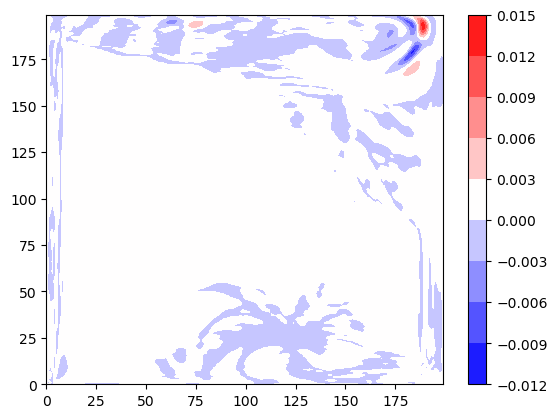

In [254]:
plt.contourf(X, Y, T_pseudo - T_true, cmap='bwr'); plt.colorbar()


In [264]:
temp_pseudo = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection_case1/T_10.64.npy")
temp_true = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection_case1_backup/T_10.64.npy")